<a href="https://colab.research.google.com/github/st4rfruit/detect/blob/main/rfdetr_sahi_inference_single_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U transformers -q
!pip install supervision -q
!pip install 'sahi[roboflow]' -q
!pip uninstall -y onnxruntime onnxruntime-gpu -q
!pip install 'onnxruntime-gpu==1.19.2' -q
print('Done — restart runtime if this is the first run')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 135.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.3/373.3 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 12.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━

## Sliced Inference on a Single Image (RF-DETR ONNX + SAHI + ViT classifier)
Model page: https://huggingface.co/MBARI-org/mbari-uav-vit-b-16

Runs SAHI sliced detection with the RF-DETR ONNX model on one image from Google Drive, then classifies each detected crop with the ViT species classifier.

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Connect Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)  # This will prompt for authorization.

Mounted at /content/drive


In [ ]:
# Copy the ONNX detector weights locally and point at the single target image on Drive
!cp "/content/drive/MyDrive/rfdetr-backgrounds/onnx_export10/rfdetr-medium.onnx" "/content/rfdetr-medium.onnx"

IMAGE_PATH = "/content/drive/MyDrive/rfdetr-backgrounds/trinity-2_20231006T165315_DSC04732.JPG"
assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"
print(f"Using image: {IMAGE_PATH}")

Using image: /content/drive/MyDrive/rfdetr-backgrounds/trinity-2_20231006T165315_DSC04732.JPG


In [ ]:
## Load ONNX detector via custom SAHI DetectionModel, load ViT classifier

import torch, numpy as np, onnxruntime as ort, supervision as sv
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sahi.models.base import DetectionModel
from sahi.prediction import ObjectPrediction
from sahi.predict import get_sliced_prediction

ONNX_MODEL_PATH      = '/content/rfdetr-medium.onnx'
CONFIDENCE_THRESHOLD = 0.40
IMAGE_SIZE           = 576   # model training resolution (tile is resized to this before the ONNX forward pass)
SLICE_SIZE           = 576   # slice/tile size fed to SAHI — experiment with this
OVERLAP              = 0.10  # slice overlap ratio — experiment with this
DEVICE               = 'cuda' if torch.cuda.is_available() else 'cpu'

# Postprocessing (merges overlapping boxes across slices)
POSTPROCESS_TYPE           = 'NMM'   # Non-Maximum Merging — best for combining boxes from adjacent slices
POSTPROCESS_MATCH_METRIC   = 'IOS'   # Intersection over Smaller — best for small objects
POSTPROCESS_CLASS_AGNOSTIC = True    # detector is single-class ('object'); species come later from the ViT
PERFORM_STANDARD_PRED      = True    # also run one full-image pass to help catch large objects the tiling can split


class RFDetrOnnxDetectionModel(DetectionModel):
    """SAHI-compatible wrapper for RF-DETR exported as ONNX.
    ONNX outputs:
      dets:   [1, 300, 4]  normalised cx,cy,w,h
      labels: [1, 300, 1]  raw logits (sigmoid → confidence)
    """

    def load_model(self):
        providers = (
            ['CUDAExecutionProvider', 'CPUExecutionProvider']
            if torch.cuda.is_available() else ['CPUExecutionProvider']
        )
        self.session      = ort.InferenceSession(self.model_path, providers=providers)
        self.input_name   = self.session.get_inputs()[0].name
        self.output_names = [o.name for o in self.session.get_outputs()]
        print(f'Active provider : {self.session.get_providers()[0]}')
        print(f'ONNX inputs     : {self.input_name}')
        print(f'ONNX outputs    : {self.output_names}')
        self.model = self.session

    def perform_inference(self, image: np.ndarray):
        h, w = image.shape[:2]
        tile = Image.fromarray(image).resize((self.image_size, self.image_size), Image.BILINEAR)
        tile = np.array(tile, dtype=np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        tile = ((tile - mean) / std).transpose(2, 0, 1)[None]
        self._original_predictions = self.session.run(self.output_names, {self.input_name: tile})
        self._tile_hw = (h, w)

    def convert_original_predictions(self, shift_amount=None, full_shape=None):
        if shift_amount is None:
            shift_amount = [0, 0]

        dets   = self._original_predictions[0][0]   # [300, 4]
        labels = self._original_predictions[1][0]   # [300, 1]
        tile_h, tile_w = self._tile_hw
        scores = 1.0 / (1.0 + np.exp(-labels[:, 0]))

        object_prediction_list = []
        for box, score in zip(dets, scores):
            if score < self.confidence_threshold:
                continue
            cx, cy, bw, bh = box
            x1 = (cx - bw / 2) * tile_w
            y1 = (cy - bh / 2) * tile_h
            x2 = (cx + bw / 2) * tile_w
            y2 = (cy + bh / 2) * tile_h
            x1, y1 = max(0.0, x1), max(0.0, y1)
            x2, y2 = min(float(tile_w), x2), min(float(tile_h), y2)
            if x2 <= x1 or y2 <= y1:
                continue
            object_prediction_list.append(
                ObjectPrediction(
                    bbox=[x1, y1, x2, y2],
                    score=float(score),
                    category_id=0,
                    category_name=self.category_mapping.get('0', 'object'),
                    shift_amount=shift_amount,
                    full_shape=full_shape,
                )
            )
        self._object_prediction_list_per_image = [object_prediction_list]


def sahi_to_sv(result) -> sv.Detections:
    """Convert SAHI PredictionResult → supervision Detections."""
    preds = result.object_prediction_list
    if not preds:
        return sv.Detections.empty()
    xyxy       = np.array([[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
                            for p in preds], dtype=np.float32)
    confidence = np.array([p.score.value for p in preds], dtype=np.float32)
    class_ids  = np.array([p.category.id for p in preds], dtype=int)
    return sv.Detections(xyxy=xyxy, confidence=confidence, class_id=class_ids)


# Instantiate detector
detection_model = RFDetrOnnxDetectionModel(
    model_path=ONNX_MODEL_PATH,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    category_mapping={'0': 'object'},
    image_size=IMAGE_SIZE,
    device=DEVICE,
)
detection_model.load_model()
print('Detection model ready\n')

# ── ViT classifier ─────────────────────────────────────────────────────────
clf_processor = AutoImageProcessor.from_pretrained('MBARI-org/mbari-uav-vit-b-16')
clf_model     = AutoModelForImageClassification.from_pretrained(
                    'MBARI-org/mbari-uav-vit-b-16').to(DEVICE)
clf_model.eval()
id2label = clf_model.config.id2label
print(f'Classifier — device: {DEVICE}  classes ({len(id2label)}): {list(id2label.values())}')

Active provider : CUDAExecutionProvider
ONNX inputs     : input
ONNX outputs    : ['dets', 'labels']
Active provider : CUDAExecutionProvider
ONNX inputs     : input
ONNX outputs    : ['dets', 'labels']
Detection model ready



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Classifier — device: cuda  classes (22): ['Batray', 'Bird', 'Boat', 'Buoy', 'Egregia', 'Foam', 'Jelly', 'Kelp', 'Mola', 'Mooring', 'Otter', 'Person', 'Pinniped', 'Poop', 'RIB', 'Reflectance', 'Secci_Disc', 'Shark', 'Surfboard', 'Wave', 'Whale', 'Wood']


In [ ]:
## Stage 1 — SAHI sliced inference with RF-DETR ONNX on the single target image

image_pil = Image.open(IMAGE_PATH).convert('RGB')

result = get_sliced_prediction(
    image_pil,
    detection_model,
    slice_height=SLICE_SIZE,
    slice_width=SLICE_SIZE,
    overlap_height_ratio=OVERLAP,
    overlap_width_ratio=OVERLAP,
    postprocess_type=POSTPROCESS_TYPE,
    postprocess_match_metric=POSTPROCESS_MATCH_METRIC,
    postprocess_class_agnostic=POSTPROCESS_CLASS_AGNOSTIC,
    perform_standard_pred=PERFORM_STANDARD_PRED,
    verbose=0,
)
detections = sahi_to_sv(result)
print(f'Detected {len(detections)} objects (conf >= {CONFIDENCE_THRESHOLD})')

Detected 108 objects (conf >= 0.4)


In [ ]:
## Stage 2 — classify each detected crop with the ViT

clf_labels, clf_scores = [], []

for x1, y1, x2, y2 in detections.xyxy.astype(int):
    crop   = image_pil.crop((x1, y1, x2, y2))
    inputs = clf_processor(images=crop, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = clf_model(**inputs).logits
    probs   = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    clf_labels.append(id2label[pred_id])
    clf_scores.append(float(probs[pred_id]))

# Write classifier class IDs back onto detections
label2id = {v: k for k, v in id2label.items()}
if len(detections) > 0:
    detections.class_id = np.array([label2id.get(l, 0) for l in clf_labels], dtype=int)

print(f'Classified {len(clf_labels)} detections:')
for lbl, scr in zip(clf_labels, clf_scores):
    print(f'  {lbl:30s}  {scr:.3f}')

Classified 108 detections:
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            0.997
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp                            1.000
  Kelp       

In [ ]:
## Stage 2b — count detections per species

from collections import Counter

counts = Counter(clf_labels)
print(f'Object counts ({sum(counts.values())} total detections):')
for label, n in counts.most_common():
    print(f'  {label:30s}  {n}')

Object counts (108 total detections):
  Kelp                            97
  Jelly                           9
  Poop                            2


Showing 9 of 108 detections (classes: ['Jelly'])


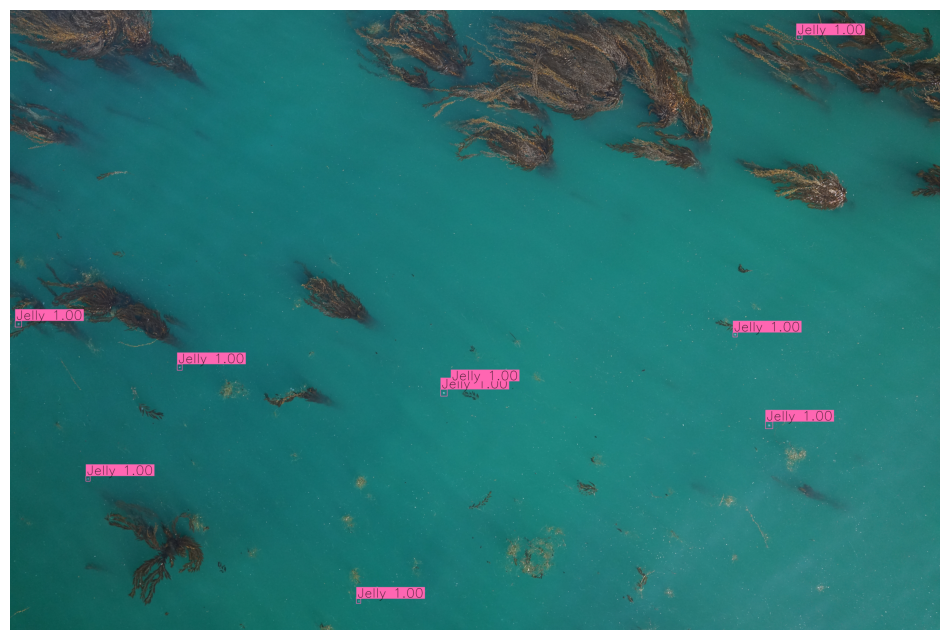

In [ ]:
## Visualize — RF-DETR + ViT prediction on the single image

# Only draw boxes for these species (set to None or [] to show everything)
SHOW_ONLY_CLASSES = ['Jelly']

color = sv.ColorPalette.from_hex([
    '#ffff00', '#ff9b00', '#ff66ff', '#3399ff', '#ff66b2', '#ff8080',
    '#b266ff', '#9999ff', '#66ffff', '#33ff99', '#66ff66', '#99ff00'
])
text_scale     = sv.calculate_optimal_text_scale(resolution_wh=image_pil.size) * 0.7  # smaller text
text_thickness = 2  # thicker/bolder text (default is 1)
thickness      = sv.calculate_optimal_line_thickness(resolution_wh=image_pil.size)

bbox_ann  = sv.BoxAnnotator(color=color, thickness=thickness)
label_ann = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_thickness=text_thickness,
)

pred_img = np.array(image_pil.copy())
if len(detections) > 0:
    if SHOW_ONLY_CLASSES:
        keep = np.array([lbl in SHOW_ONLY_CLASSES for lbl in clf_labels])
    else:
        keep = np.ones(len(detections), dtype=bool)

    show_detections = detections[keep]
    show_labels = [lbl for lbl, k in zip(clf_labels, keep) if k]
    show_scores = [scr for scr, k in zip(clf_scores, keep) if k]

    print(f'Showing {keep.sum()} of {len(detections)} detections (classes: {SHOW_ONLY_CLASSES or "all"})')

    if len(show_labels) > 0:
        pred_text = [f'{lbl} {scr:.2f}' for lbl, scr in zip(show_labels, show_scores)]
        pred_img = bbox_ann.annotate(pred_img, show_detections)
        pred_img = label_ann.annotate(pred_img, show_detections, pred_text)

sv.plot_image(pred_img[..., ::-1], size=(12, 12))

In [ ]:
# Export the full-resolution annotated prediction image to Drive
EXPORT_DIR = "/content/drive/MyDrive/rfdetr-backgrounds/exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

export_filename = os.path.splitext(os.path.basename(IMAGE_PATH))[0] + "_prediction.png"
export_path     = os.path.join(EXPORT_DIR, export_filename)

# pred_img is a plain RGB array in this notebook (no BGR conversion happened
# above), so PIL can save it directly at full resolution — no color fixup needed.
Image.fromarray(pred_img).save(export_path)
print(f'Saved full-resolution prediction image: {export_path}')

Saved full-resolution prediction image: /content/drive/MyDrive/rfdetr-backgrounds/exports/trinity-2_20231006T165315_DSC04732_prediction.png
